# Fit Genius — Deadlift Dataset Exploration

**Build-order step 1.** Understand the deadlift data and its label distributions before training.

Source: `CSV_files/coords_DL_C.csv` — raw 132-dim MediaPipe landmarks with a combined
phase/form `class` label (DanielGuarnizo repo style). A bench-press file ships alongside it
but bench press is **not** a Fit Genius target exercise.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Locate the repo root (the folder that contains `backend/`) regardless of cwd.
root = Path.cwd()
while not (root / "backend").exists() and root != root.parent:
    root = root.parent
DATA = root / "backend" / "training" / "data"
FIGS = (root / "notebooks" / "figures"); FIGS.mkdir(parents=True, exist_ok=True)
print("repo root :", root)
print("data dir  :", DATA)

LANDMARK_COLS = [f"{a}{i}" for i in range(1, 34) for a in ("x", "y", "z", "v")]
print("expected landmark feature count:", len(LANDMARK_COLS), "(33 landmarks x [x,y,z,v])")

repo root : D:\Fit_genius
data dir  : D:\Fit_genius\backend\training\data
expected landmark feature count: 132 (33 landmarks x [x,y,z,v])


## Raw MediaPipe landmarks (`coords_DL_C.csv`)

In [2]:
dl = pd.read_csv(DATA / "CSV_files" / "coords_DL_C.csv")
print("coords_DL_C.csv  shape:", dl.shape)
print("feature columns :", dl.shape[1] - 1, "(132 landmark features expected)")
print("null cells      :", int(dl.isnull().sum().sum()))
dl.head(3)

coords_DL_C.csv  shape: (2478, 133)
feature columns : 132 (132 landmark features expected)
null cells      : 0


,class,x1,y1,z1,v1,x2,y2,z2,v2,x3,...,z31,v31,x32,y32,z32,v32,x33,y33,z33,v33
0,up,0.383222,0.202043,-0.444070,0.999768,0.390770,0.181416,-0.485579,0.999488,0.400591,...,0.790114,0.794656,0.532802,0.928815,-0.604931,0.986127,0.281013,0.854695,0.648649,0.928754
1,up,0.370170,0.190972,-0.536418,0.999780,0.378685,0.170899,-0.582296,0.999517,0.387949,...,0.933979,0.839177,0.531191,0.929268,-0.673396,0.989410,0.279888,0.854595,0.781246,0.949858
2,up,0.370131,0.190748,-0.527947,0.999776,0.378677,0.170659,-0.572717,0.999508,0.387952,...,0.930592,0.841491,0.531170,0.929279,-0.674023,0.989503,0.279890,0.854562,0.779460,0.950651


### Class distribution
Classes bundle **phase** (up/down) with a **form** tag (low, roll, back …).

class
up           523
down_low     512
down_roll    445
down         387
up_roll      367
up_back      244

total frames: 2478


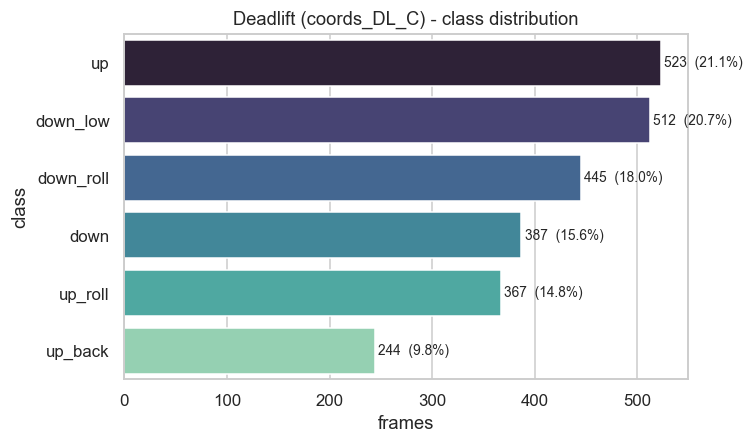

In [3]:
counts = dl["class"].value_counts()
print(counts.to_string()); print("\ntotal frames:", len(dl))

fig, ax = plt.subplots(figsize=(7, 4.2))
sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="mako")
for i, v in enumerate(counts.values):
    ax.text(v + 3, i, f"{v}  ({v/len(dl)*100:.1f}%)", va="center", fontsize=9)
ax.set(title="Deadlift (coords_DL_C) - class distribution", xlabel="frames", ylabel="class")
plt.tight_layout(); plt.savefig(FIGS / "deadlift_raw_class_dist.png"); plt.show()

### Phase vs. form breakdown

PHASE balance:
phase
down    1344
up      1134
Name: count, dtype: int64 

FORM tag balance:
form
correct    910
roll       812
low        512
back       244
Name: count, dtype: int64


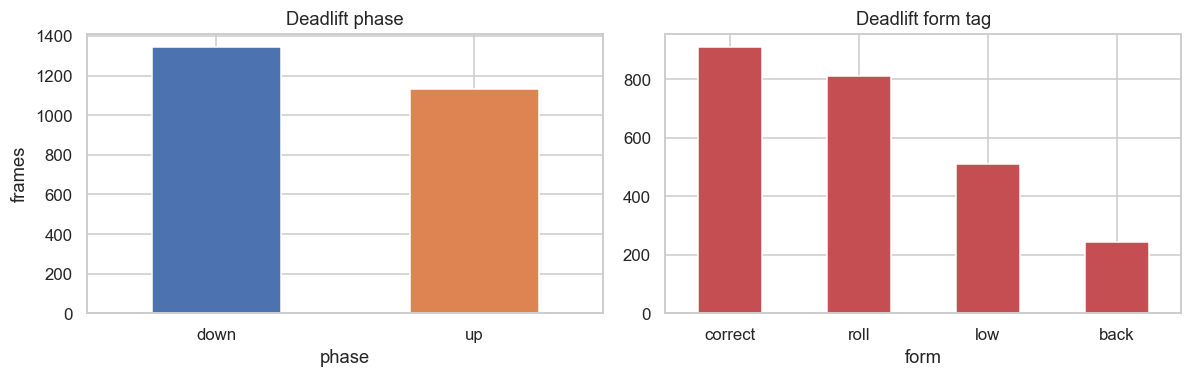

In [4]:
def phase_of(c):  return "up" if c.startswith("up") else "down"
def form_of(c):
    parts = c.split("_", 1)
    return "correct" if len(parts) == 1 else parts[1]

dl["phase"] = dl["class"].map(phase_of)
dl["form"]  = dl["class"].map(form_of)
print("PHASE balance:"); print(dl["phase"].value_counts(), "\n")
print("FORM tag balance:"); print(dl["form"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
dl["phase"].value_counts().plot.bar(ax=axes[0], color=["#4c72b0", "#dd8452"], rot=0)
axes[0].set(title="Deadlift phase", ylabel="frames")
dl["form"].value_counts().plot.bar(ax=axes[1], color="#c44e52", rot=0)
axes[1].set(title="Deadlift form tag")
plt.tight_layout(); plt.savefig(FIGS / "deadlift_raw_phase_form.png"); plt.show()

### Aside — bench-press file (not a target exercise)

In [5]:
# A bench-press file (coords_BP_C.csv) also ships with the dataset.
# Bench press is NOT a Fit Genius target exercise -- shown here only for awareness.
bp = pd.read_csv(DATA / "CSV_files" / "coords_BP_C.csv")
print("coords_BP_C.csv shape:", bp.shape, "(NOT a target exercise)")
print(bp["class"].value_counts().to_string())

coords_BP_C.csv shape: (1841, 133) (NOT a target exercise)
class
up_roll       533
down          447
up_close      444
down_close    211
up            206


## Summary — deadlift

- 2,478 frames, **6 classes**, no nulls, full 132-dim landmark features — richest of the raw sets.
- Form errors captured: **low** (insufficient hip height), **roll** (back rounding), **back**
  (hyperextension on lockout). Phase split is roughly balanced (`up`-family vs `down`-family).
- Like the squat raw set, there is **no `frame`/`video` column**, so sequence windowing relies on
  in-file row order.
- `coords_BP_C.csv` (bench press) is present but out of scope for the squat/deadlift models.